In [1]:
!pip install gdown
import gdown

# File ID from your link
file_id = "18KwSR9aVTZRNaOVF76VE9USSEkqnYzzQ"

# Download zip file
gdown.download(f"https://drive.google.com/uc?id={file_id}", "bank-data.zip", quiet=False)

Downloading...
From: https://drive.google.com/uc?id=18KwSR9aVTZRNaOVF76VE9USSEkqnYzzQ
To: /content/bank-data.zip
100%|██████████| 516k/516k [00:00<00:00, 27.2MB/s]


'bank-data.zip'

In [2]:
import zipfile
import os

zip_path = "bank-data.zip"
extract_path = "/content/bank-data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Check extracted files
print(os.listdir(extract_path))

['bank-data', '__MACOSX']


In [3]:
print(os.listdir("/content/bank-data/bank-data"))

['.DS_Store', 'bank-full.csv']


In [4]:
# Import libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix



In [5]:
# Load dataset
df = pd.read_csv("/content/bank-data/bank-data/bank-full.csv", sep=';')

# Display first few rows
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [6]:
# Convert target variable (yes/no → 1/0)
df['y'] = df['y'].map({'yes': 1, 'no': 0})

# Encode categorical columns
label_encoders = {}
for col in df.select_dtypes(include=['object']).columns:
    if col != 'y':
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        label_encoders[col] = le

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,4,1,2,0,2143,1,0,2,5,8,261,1,-1,0,3,0
1,44,9,2,1,0,29,1,0,2,5,8,151,1,-1,0,3,0
2,33,2,1,1,0,2,1,1,2,5,8,76,1,-1,0,3,0
3,47,1,1,3,0,1506,1,0,2,5,8,92,1,-1,0,3,0
4,33,11,2,3,0,1,0,0,2,5,8,198,1,-1,0,3,0


In [7]:
# Split features and target
X = df.drop('y', axis=1)
y = df['y']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [9]:
# Logistic Regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [12]:
# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.8878690699988941

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.98      0.94      7952
           1       0.60      0.22      0.32      1091

    accuracy                           0.89      9043
   macro avg       0.75      0.60      0.63      9043
weighted avg       0.86      0.89      0.86      9043



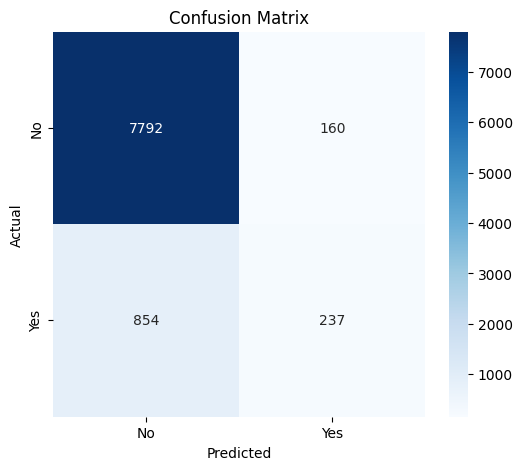

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,        # show numbers
            fmt='d',           # integer format
            cmap='Blues',      # color theme
            xticklabels=['No', 'Yes'],
            yticklabels=['No', 'Yes'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()